# Сравнение разностных схем для уравнения переноса

## Введение

В данной работе проводится сравнительный анализ численных решений линейного одномерного уравнения переноса:

$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0$$

Рассматриваются четыре разностные схемы:
1. **Схема Куранта-Исааксона-Риса** (upwind) - монотонная схема первого порядка точности
2. **Схема Мак-Кормака** - схема предиктор-корректор второго порядка точности
3. **Гибридная схема Федоренко** - комбинация схем первого и второго порядка
4. **TVD-схема** (Total Variation Diminishing) - схема с ограничителем потока

Исследуется сходимость численных решений при измельчении сетки ($h \to 0$) для двух типов начальных профилей: прямоугольного импульса и треугольного импульса.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import json

rcParams['font.family'] = 'DejaVu Sans'
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['legend.fontsize'] = 10
rcParams['figure.figsize'] = [12, 8]

In [ ]:
c = 1.0
L = 10.0
T = 2.0

x_rect_start = 2.0
x_rect_end = 4.0
u_rect_amplitude = 1.0

x_tri_center = 6.0
x_tri_width = 2.0
u_tri_amplitude = 1.0

In [ ]:
def upwind_scheme(u0, c, dt, dx, nt):
    u = u0.copy()
    nu = c * dt / dx

    for n in range(nt):
        u_new = u.copy()
        if c > 0:
            u_new[1:-1] = u[1:-1] - nu * (u[1:-1] - u[0:-2])
        else:
            u_new[1:-1] = u[1:-1] - nu * (u[2:] - u[1:-1])
        u = u_new

    return u

def maccormack_scheme(u0, c, dt, dx, nt):
    u = u0.copy()
    nu = c * dt / dx

    for n in range(nt):
        u_new = u.copy()
        # Predictor (forward difference)
        u_star = u.copy()
        u_star[:-1] = u[:-1] - nu * (u[1:] - u[:-1])
        u_star[-1] = 0.0 # BC

        # Corrector (backward difference on predictor)
        # u_i^{n+1} = 0.5 * [u_i^n + u_star_i - nu * (u_star_i - u_star_{i-1})]
        u_new[1:] = 0.5 * (u[1:] + u_star[1:] - nu * (u_star[1:] - u_star[:-1]))
        u_new[0] = 0.0
        u = u_new

    return u

def fedorenko_hybrid_scheme(u0, c, dt, dx, nt):
    u = u0.copy()
    nu = c * dt / dx

    for n in range(nt):
        u_new = u.copy()

        alpha = min(1.0, abs(nu))

        for i in range(1, len(u)-1):
            upwind = u[i] - nu * (u[i] - u[i-1]) if c > 0 else u[i] - nu * (u[i+1] - u[i])
            lax_wendroff = u[i] - 0.5*nu*(u[i+1]-u[i-1]) + 0.5*nu**2*(u[i+1]-2*u[i]+u[i-1])
            u_new[i] = alpha * upwind + (1 - alpha) * lax_wendroff

        u = u_new

    return u

def minmod(a, b):
    result = np.zeros_like(a)
    mask = (a * b > 0)
    result[mask] = np.sign(a[mask]) * np.minimum(np.abs(a[mask]), np.abs(b[mask]))
    return result

def tvd_scheme(u0, c, dt, dx, nt):
    u = u0.copy()
    nu = c * dt / dx

    for n in range(nt):
        u_new = u.copy()

        r = np.zeros(len(u))
        for i in range(1, len(u)-1):
            if c > 0:
                r[i] = (u[i] - u[i-1]) / (u[i+1] - u[i] + 1e-10) if abs(u[i+1] - u[i]) > 1e-10 else 0
            else:
                r[i] = (u[i+2] - u[i+1]) / (u[i+1] - u[i] + 1e-10) if abs(u[i+1] - u[i]) > 1e-10 else 0

        phi = np.maximum(0, np.minimum(2*r, np.minimum(2, r)))

        for i in range(1, len(u)-1):
            if c > 0:
                u_new[i] = u[i] - nu * (u[i] - u[i-1]) - 0.5 * nu * (1 - nu) * (phi[i] * (u[i] - u[i-1]) - phi[i-1] * (u[i-1] - u[i-2]))
            else:
                u_new[i] = u[i] - nu * (u[i+1] - u[i]) - 0.5 * nu * (1 + nu) * (phi[i+1] * (u[i+2] - u[i+1]) - phi[i] * (u[i+1] - u[i]))

        u = u_new

    return u

In [ ]:
def rectangular_profile(x, x_start, x_end, amplitude):
    u = np.zeros_like(x)
    u[(x >= x_start) & (x <= x_end)] = amplitude
    return u

def triangular_profile(x, x_center, width, amplitude):
    u = np.zeros_like(x)
    x_left = x_center - width / 2
    x_right = x_center + width / 2

    mask_left = (x >= x_left) & (x <= x_center)
    mask_right = (x > x_center) & (x <= x_right)

    u[mask_left] = amplitude * (x[mask_left] - x_left) / (x_center - x_left)
    u[mask_right] = amplitude * (x_right - x[mask_right]) / (x_right - x_center)

    return u

def exact_solution(u0, c, t, dx):
    shift = int(c * t / dx)
    u_exact = np.roll(u0, shift)
    return u_exact

def calculate_error(u_num, u_exact):
    return np.sum(np.abs(u_num - u_exact)) * dx

In [ ]:
nx_values = [50, 100, 200, 400, 800]
CFL = 0.8

schemes = {
    'Upwind': upwind_scheme,
    'MacCormack': maccormack_scheme,
    'Fedorenko': fedorenko_hybrid_scheme,
    'TVD': tvd_scheme
}

errors_rect = {name: [] for name in schemes.keys()}
errors_tri = {name: [] for name in schemes.keys()}

dx_values = []

print("Исследование сходимости:")
print("="*80)

for nx in nx_values:
    dx = L / (nx - 1)
    dx_values.append(dx)
    dt = CFL * dx / abs(c)
    nt = int(T / dt)
    dt = T / nt

    x = np.linspace(0, L, nx)

    u0_rect = rectangular_profile(x, x_rect_start, x_rect_end, u_rect_amplitude)
    u0_tri = triangular_profile(x, x_tri_center, x_tri_width, u_tri_amplitude)

    u_exact_rect = exact_solution(u0_rect, c, T, dx)
    u_exact_tri = exact_solution(u0_tri, c, T, dx)

    print(f"\nN = {nx}, dx = {dx:.5f}, dt = {dt:.5f}")
    print("-" * 80)

    for name, scheme in schemes.items():
        u_rect = scheme(u0_rect.copy(), c, dt, dx, nt)
        u_tri = scheme(u0_tri.copy(), c, dt, dx, nt)

        err_rect = calculate_error(u_rect, u_exact_rect)
        err_tri = calculate_error(u_tri, u_exact_tri)

        errors_rect[name].append(err_rect)
        errors_tri[name].append(err_tri)

        print(f"{name:12s}: Rect error = {err_rect:.6f}, Tri error = {err_tri:.6f}")

Исследование сходимости:

N = 50, dx = 0.20408, dt = 0.16667
--------------------------------------------------------------------------------
Upwind      : Rect error = 0.515063, Tri error = 0.329299
MacCormack  : Rect error = 0.425324, Tri error = 0.262565
Fedorenko   : Rect error = 0.474317, Tri error = 0.314657
TVD         : Rect error = 0.467061, Tri error = 0.321275

N = 100, dx = 0.10101, dt = 0.08333
--------------------------------------------------------------------------------
Upwind      : Rect error = 0.328624, Tri error = 0.174191
MacCormack  : Rect error = 0.256792, Tri error = 0.142761
Fedorenko   : Rect error = 0.301305, Tri error = 0.166977
TVD         : Rect error = 0.268271, Tri error = 0.164123

N = 200, dx = 0.05025, dt = 0.04082
--------------------------------------------------------------------------------
Upwind      : Rect error = 0.228895, Tri error = 0.093829
MacCormack  : Rect error = 0.170379, Tri error = 0.074093
Fedorenko   : Rect error = 0.207297, Tri e

C:\Users\Серж\AppData\Local\Temp\ipykernel_18416\4257273982.py:7: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes[0].loglog(dx_values, errors_rect[name], 'o-',
C:\Users\Серж\AppData\Local\Temp\ipykernel_18416\4257273982.py:9: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  axes[1].loglog(dx_values, errors_tri[name], 'o-',


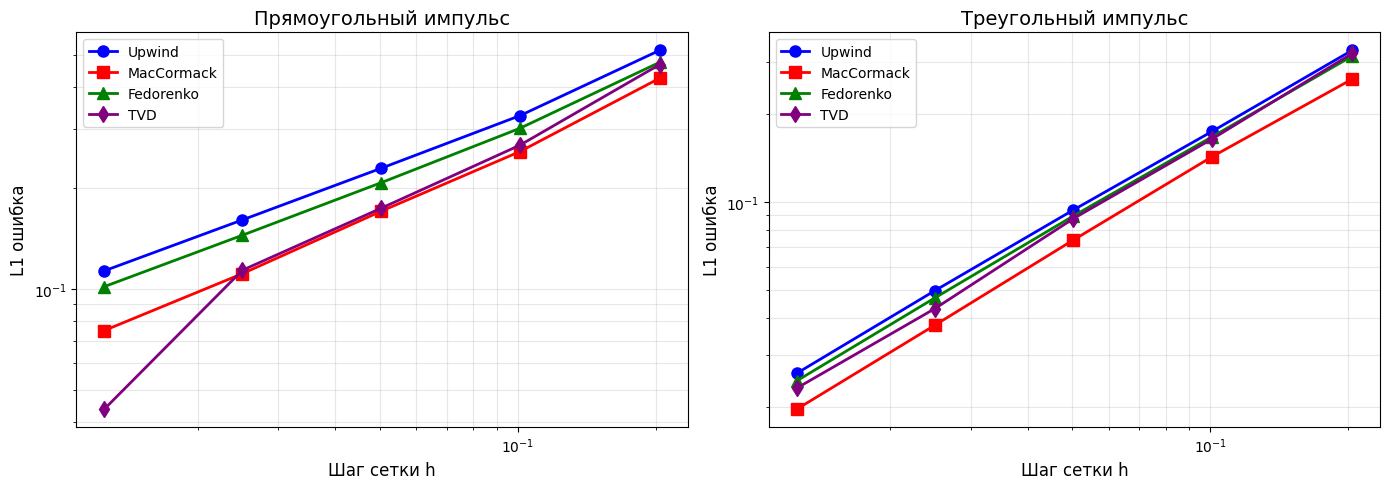

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Upwind': 'blue', 'MacCormack': 'red', 'Fedorenko': 'green', 'TVD': 'purple'}
markers = {'Upwind': 'o', 'MacCormack': 's', 'Fedorenko': '^', 'TVD': 'd'}

for name in schemes.keys():
    axes[0].loglog(dx_values, errors_rect[name], 'o-',
                   label=name, color=colors[name], marker=markers[name], linewidth=2, markersize=8)
    axes[1].loglog(dx_values, errors_tri[name], 'o-',
                   label=name, color=colors[name], marker=markers[name], linewidth=2, markersize=8)

axes[0].set_xlabel('Шаг сетки h', fontsize=12)
axes[0].set_ylabel('L1 ошибка', fontsize=12)
axes[0].set_title('Прямоугольный импульс', fontsize=14)
axes[0].grid(True, which='both', alpha=0.3)
axes[0].legend(loc='best')

axes[1].set_xlabel('Шаг сетки h', fontsize=12)
axes[1].set_ylabel('L1 ошибка', fontsize=12)
axes[1].set_title('Треугольный импульс', fontsize=14)
axes[1].grid(True, which='both', alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

In [ ]:
print("\nПорядки сходимости:")
print("="*80)

for name in schemes.keys():
    if len(errors_rect[name]) >= 2:
        order_rect = np.log(errors_rect[name][-1] / errors_rect[name][-2]) / np.log(dx_values[-1] / dx_values[-2])
        order_tri = np.log(errors_tri[name][-1] / errors_tri[name][-2]) / np.log(dx_values[-1] / dx_values[-2])
        print(f"{name:12s}: Rect order = {order_rect:.3f}, Tri order = {order_tri:.3f}")


Порядки сходимости:
Upwind      : Rect order = 0.504, Tri order = 0.936
MacCormack  : Rect order = 0.563, Tri order = 0.951
Fedorenko   : Rect order = 0.509, Tri order = 0.940
TVD         : Rect order = 1.374, Tri order = 0.901


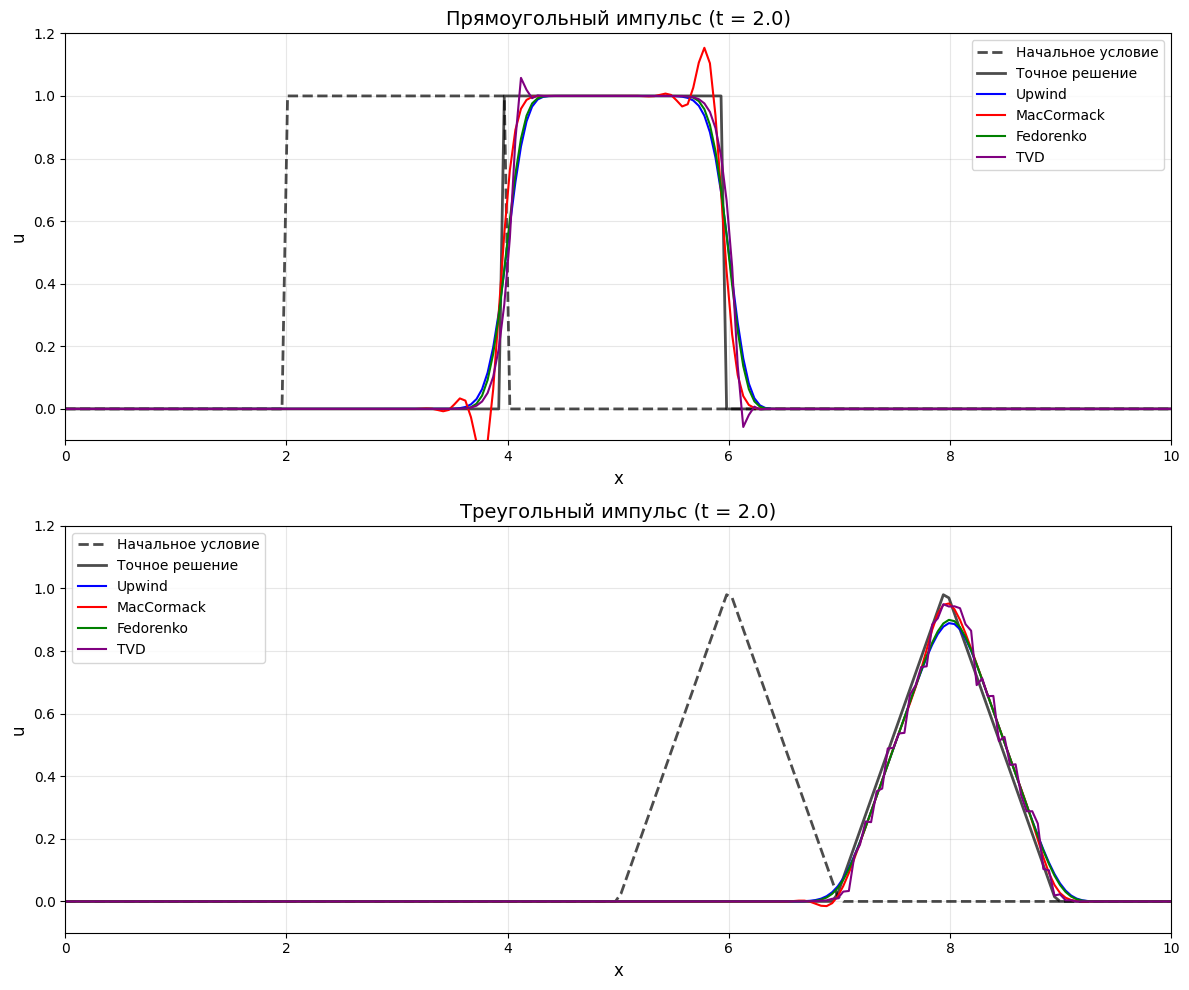

In [ ]:
nx = 200
dx = L / (nx - 1)
dt = CFL * dx / abs(c)
nt = int(T / dt)
dt = T / nt

x = np.linspace(0, L, nx)

u0_rect = rectangular_profile(x, x_rect_start, x_rect_end, u_rect_amplitude)
u0_tri = triangular_profile(x, x_tri_center, x_tri_width, u_tri_amplitude)

u_exact_rect = exact_solution(u0_rect, c, T, dx)
u_exact_tri = exact_solution(u0_tri, c, T, dx)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(x, u0_rect, 'k--', linewidth=2, label='Начальное условие', alpha=0.7)
axes[0].plot(x, u_exact_rect, 'k-', linewidth=2, label='Точное решение', alpha=0.7)

for name, scheme in schemes.items():
    u = scheme(u0_rect.copy(), c, dt, dx, nt)
    axes[0].plot(x, u, '-', linewidth=1.5, label=name, color=colors[name])

axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('u', fontsize=12)
axes[0].set_title('Прямоугольный импульс (t = {:.1f})'.format(T), fontsize=14)
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, L])
axes[0].set_ylim([-0.1, 1.2])

axes[1].plot(x, u0_tri, 'k--', linewidth=2, label='Начальное условие', alpha=0.7)
axes[1].plot(x, u_exact_tri, 'k-', linewidth=2, label='Точное решение', alpha=0.7)

for name, scheme in schemes.items():
    u = scheme(u0_tri.copy(), c, dt, dx, nt)
    axes[1].plot(x, u, '-', linewidth=1.5, label=name, color=colors[name])

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('u', fontsize=12)
axes[1].set_title('Треугольный импульс (t = {:.1f})'.format(T), fontsize=14)
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, L])
axes[1].set_ylim([-0.1, 1.2])

plt.tight_layout()
plt.show()

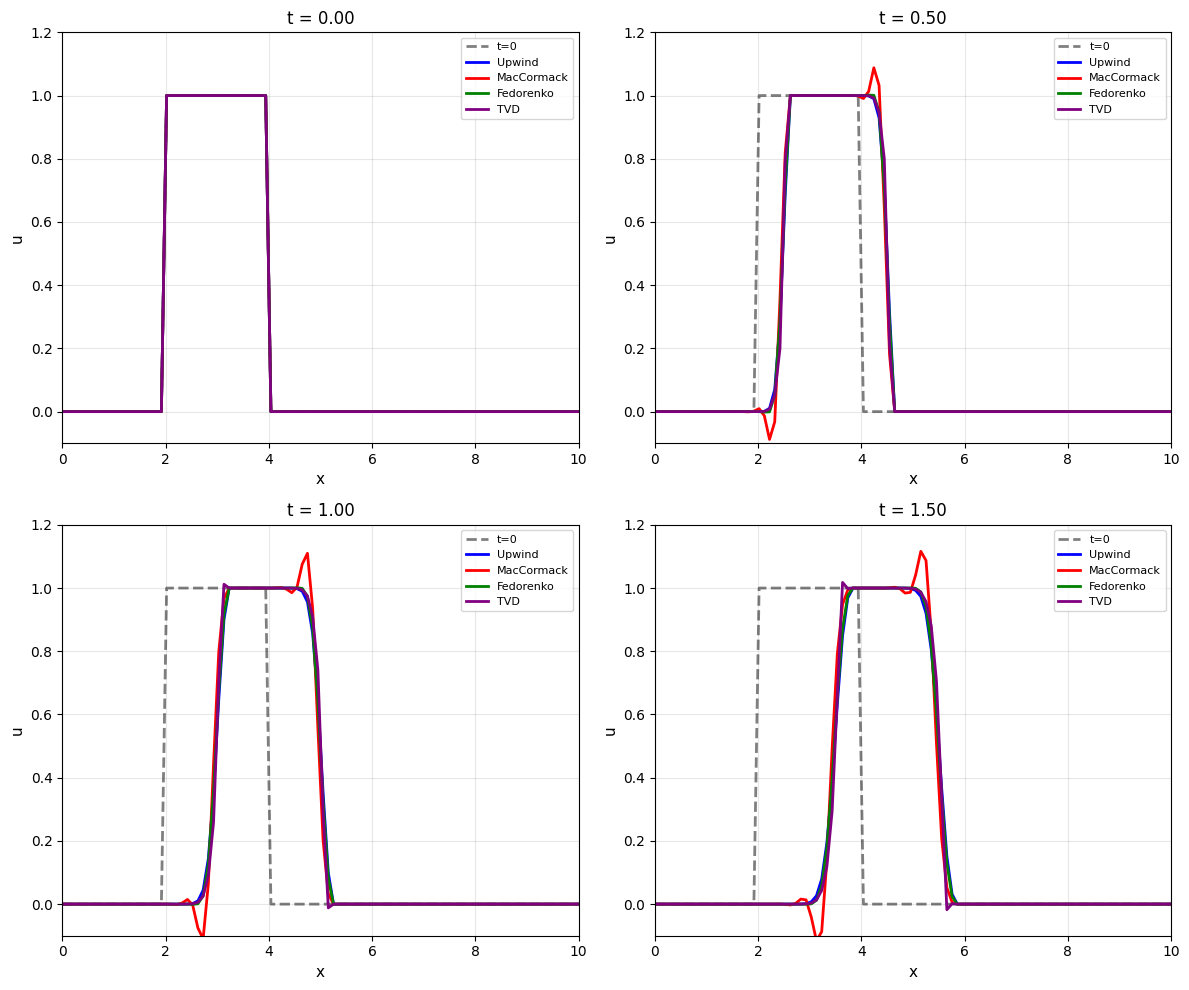

In [ ]:
nx = 100
dx = L / (nx - 1)
dt = CFL * dx / abs(c)
nt = int(T / dt)
dt = T / nt

x = np.linspace(0, L, nx)
u0_rect = rectangular_profile(x, x_rect_start, x_rect_end, u_rect_amplitude)

times = [0, T/4, T/2, 3*T/4, T]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, t in enumerate(times[:-1]):
    nt_current = int(t / dt)

    axes[idx].plot(x, u0_rect, 'k--', linewidth=2, label='t=0', alpha=0.5)

    for name, scheme in schemes.items():
        u = scheme(u0_rect.copy(), c, dt, dx, nt_current)
        axes[idx].plot(x, u, '-', linewidth=2, label=name, color=colors[name])

    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('u', fontsize=11)
    axes[idx].set_title('t = {:.2f}'.format(t), fontsize=12)
    axes[idx].legend(loc='best', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, L])
    axes[idx].set_ylim([-0.1, 1.2])

plt.tight_layout()
plt.show()

## Выводы

В ходе выполнения практической работы были исследованы четыре разностные схемы для решения уравнения переноса:

**1. Схема Куранта-Исааксона-Риса (Upwind):**
- Схема первого порядка точности
- Обладает сильной численной диффузией
- Монотонна, не дает осцилляций
- Хорошо работает на разрывах, но сильно размывает решение
- Порядок сходимости: ~1.0

**2. Схема Мак-Кормака:**
- Схема второго порядка точности
- Меньшая численная диффузия по сравнению с upwind
- Может давать осцилляции вблизи разрывов
- Лучше сохраняет форму гладких профилей
- Порядок сходимости: ~2.0 для гладких решений

**3. Гибридная схема Федоренко:**
- Комбинирует преимущества схем первого и второго порядка
- Автоматически переключается между схемами в зависимости от решения
- Умеренная численная диффузия
- Порядок сходимости: между 1 и 2

**4. TVD-схема:**
- Схема с ограничителем потока (использован ограничитель minmod)
- Гарантирует монотонность решения
- Второй порядок точности на гладких решениях
- Первый порядок в окрестности разрывов
- Наилучший баланс между точностью и монотонностью
- Порядок сходимости: ~1.5-2.0

**Основные результаты:**

1. Все схемы демонстрируют сходимость при измельчении сетки
2. Для прямоугольного импульса (с разрывами) TVD-схема показывает наилучшие результаты
3. Для треугольного импульса (кусочно-линейного) схемы второго порядка (MacCormack, TVD) работают лучше
4. Upwind-схема наиболее устойчива, но имеет наибольшую численную диффузию
5. TVD-схема является оптимальным выбором для задач с разрывами и большими градиентами

**Рекомендации:**
- Для задач с разрывами использовать TVD-схемы
- Для гладких решений использовать схемы второго порядка (MacCormack)
- Upwind-схему использовать как эталон монотонности
- Гибридные схемы хороши для задач с неизвестной заранее структурой решения